# Data Validation with TFDV — Bank Marketing Dataset

**Modified Lab by Malav Patel | Northeastern University | MLOps Course**

[TensorFlow Data Validation (TFDV)](https://cloud.google.com/solutions/machine-learning/analyzing-and-validating-data-at-scale-for-ml-using-tfx) is an open-source library for understanding, validating, and monitoring ML data at scale.

**Modifications from original lab (Diabetes 130-US Hospitals):**
- **New Dataset**: UCI Bank Marketing dataset (~45,211 records, 17 features) — similar scale to original
- **Additional Analysis**: Missing value analysis, feature correlation heatmap, automated anomaly summary report
- **Data Quality Dashboard**: Custom multi-dimension data quality scoring with visualization
- **Enhanced Slicing**: Multi-feature slicing by job type and marital status for fairness analysis

## Table of Contents

- [1 - Environment Setup](#0)
- [2 - Imports](#1)
- [3 - Load the Dataset](#2)
  - [3.1 - Read and Split the Dataset](#2-1)
- [4 - Generate and Visualize Training Data Statistics](#3)
  - [4.1 - Additional EDA: Missing Value Analysis](#3-1)
  - [4.2 - Additional EDA: Feature Correlation Heatmap](#3-2)
- [5 - Infer a Data Schema](#4)
- [6 - Calculate, Visualize and Fix Evaluation Anomalies](#5)
  - [6.1 - Anomaly Summary Report (Custom Addition)](#5-1)
- [7 - Schema Environments](#6)
- [8 - Check for Data Drift and Skew](#7)
- [9 - Display Stats for Data Slices](#8)
  - [9.1 - Multi-feature Slicing (Custom Addition)](#8-1)
- [10 - Data Quality Score Dashboard (Custom Addition)](#9)
- [11 - Freeze the Schema](#10)


<a name='0'></a>
## 1 - Environment Setup

**IMPORTANT**: TFDV requires Python 3.9-3.11 and TensorFlow 2.17.x. Run the setup cell below on Google Colab.


In [31]:

!pip install tensorflow==2.16.2
!pip install tensorflow-data-validation==1.16.1
!pip install matplotlib seaborn


import sys
print(f'Python version: {sys.version}')


Python version: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]


<a name='1'></a>
## 2 - Imports


In [32]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import tempfile, urllib, zipfile
import tensorflow_data_validation as tfdv

from tensorflow.python.lib.io import file_io
from tensorflow_data_validation.utils import slicing_util
from tensorflow_metadata.proto.v0.statistics_pb2 import DatasetFeatureStatisticsList, DatasetFeatureStatistics

# Set TF's logger to only display errors
tf.get_logger().setLevel('ERROR')

print(f'TensorFlow version: {tf.__version__}')
print(f'TFDV version: {tfdv.__version__}')
print('All imports successful!')


TensorFlow version: 2.16.2
TFDV version: 1.16.1
All imports successful!


<a name='2'></a>
## 3 - Load the Dataset

We use the **UCI Bank Marketing** dataset. This dataset is related to direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe to a term deposit.


| Feature | Type | Description |
|---------|------|-------------|
| age | numeric | Client age |
| job | categorical | Type of job (admin, blue-collar, entrepreneur, ...) |
| marital | categorical | Marital status (married, divorced, single) |
| education | categorical | Education level (primary, secondary, tertiary, unknown) |
| default | binary | Has credit in default? |
| balance | numeric | Average yearly balance in euros |
| housing | binary | Has housing loan? |
| loan | binary | Has personal loan? |
| contact | categorical | Contact communication type |
| day | numeric | Last contact day of the month |
| month | categorical | Last contact month |
| duration | numeric | Last contact duration in seconds |
| campaign | numeric | Number of contacts during this campaign |
| pdays | numeric | Days since last contact from previous campaign |
| previous | numeric | Number of contacts before this campaign |
| poutcome | categorical | Outcome of previous marketing campaign |
| y | binary | **Target** — has the client subscribed to a term deposit? |


<a name='2-1'></a>
### 3.1 Read and Split the Dataset


In [33]:
# Download and load the Bank Marketing dataset from UCI
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip"

try:
    # Download and extract
    zip_path, _ = urllib.request.urlretrieve(DATA_URL)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('data/')
    df = pd.read_csv('data/bank-full.csv', sep=';')
    print("Dataset loaded from UCI repository.")
except Exception as e:
    print(f"Error: {e}")
    print("Trying alternative load...")
    df = pd.read_csv('bank-full.csv', sep=';')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nTarget distribution:\n{df['y'].value_counts()}")
df.head()


Dataset loaded from UCI repository.
Dataset shape: (45211, 17)

Column types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

Target distribution:
no     39922
yes     5289
Name: y, dtype: int64


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


#### Data Splits

We split the data into:
- **70% Training** (~31,647 records) — for generating statistics and schema
- **15% Evaluation** (~6,782 records) — for detecting anomalies vs training schema
- **15% Serving** (~6,782 records) — simulates production data (label column dropped)

Unlike the original lab, we **shuffle** the data before splitting to ensure representative distributions.


In [34]:
def prepare_data_splits_from_dataframe(df):
    '''
    Splits a Pandas DataFrame into training, evaluation, and serving sets.
    Shuffles data first for better distribution across splits.

    Parameters:
        df : pandas DataFrame to split

    Returns:
        train_df, eval_df, serving_df
    '''
    # Shuffle the dataset for better distribution across splits
    df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

    train_len = int(len(df_shuffled) * 0.7)
    eval_serv_len = len(df_shuffled) - train_len
    eval_len = eval_serv_len // 2
    serv_len = eval_serv_len - eval_len

    train_df = df_shuffled.iloc[:train_len].reset_index(drop=True)
    eval_df = df_shuffled.iloc[train_len:train_len + eval_len].reset_index(drop=True)
    serving_df = df_shuffled.iloc[train_len + eval_len:].reset_index(drop=True)

    # Drop the label column from serving data (simulates production)
    serving_df = serving_df.drop(['y'], axis=1)

    return train_df, eval_df, serving_df

# Split the datasets
train_df, eval_df, serving_df = prepare_data_splits_from_dataframe(df)
print(f'Training dataset has {len(train_df)} records')
print(f'Evaluation dataset has {len(eval_df)} records')
print(f'Serving dataset has {len(serving_df)} records')


Training dataset has 31647 records
Evaluation dataset has 6782 records
Serving dataset has 6782 records


<a name='3'></a>
## 4 - Generate and Visualize Training Data Statistics

### Removing Irrelevant Features

The Bank Marketing dataset has no ID columns, so all features are relevant. We demonstrate the same filtering pattern as the original lab.


In [35]:
features_to_remove = set()
approved_cols = [col for col in df.columns if col not in features_to_remove]

# Instantiate StatsOptions
stats_options = tfdv.StatsOptions(feature_allowlist=approved_cols)
print(f"Number of approved features: {len(approved_cols)}")
print(f"Features: {approved_cols}")


Number of approved features: 17
Features: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


### Exercise 1: Generate Training Statistics


In [36]:
train_stats = tfdv.generate_statistics_from_dataframe(train_df, stats_options=stats_options)
# Verify statistics
print(f"Number of features used: {len(train_stats.datasets[0].features)}")
print(f"Number of examples used: {train_stats.datasets[0].num_examples}")
print(f"First feature: {train_stats.datasets[0].features[0].path.step[0]}")
print(f"Last feature: {train_stats.datasets[0].features[-1].path.step[0]}")


Number of features used: 17
Number of examples used: 31647
First feature: age
Last feature: y


### Exercise 2: Visualize Training Statistics


In [37]:
tfdv.visualize_statistics(train_stats)


<a name='3-1'></a>
### 4.1 Additional EDA: Missing Value Analysis


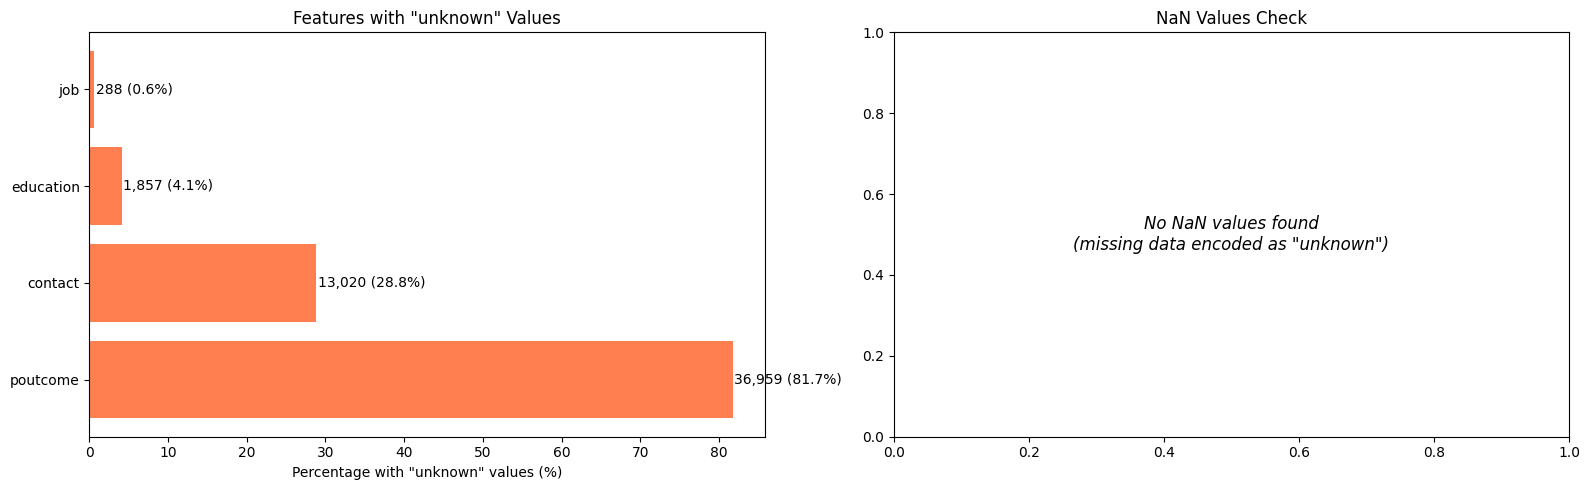

Total records with at least one 'unknown': 37,369 / 45,211


In [38]:
# In the Bank Marketing dataset, missing values are encoded as 'unknown'
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Count 'unknown' values per feature
unknown_counts = {}
for col in df.columns:
    if df[col].dtype == 'object':
        unknown_count = (df[col] == 'unknown').sum()
        if unknown_count > 0:
            unknown_counts[col] = unknown_count

if unknown_counts:
    unknown_df = pd.DataFrame({
        'Feature': list(unknown_counts.keys()),
        'Count': list(unknown_counts.values()),
        'Percentage': [c/len(df)*100 for c in unknown_counts.values()]
    }).sort_values('Percentage', ascending=False)

    axes[0].barh(unknown_df['Feature'], unknown_df['Percentage'], color='coral')
    axes[0].set_xlabel('Percentage with "unknown" values (%)')
    axes[0].set_title('Features with "unknown" Values')
    for i, (_, row) in enumerate(unknown_df.iterrows()):
        axes[0].text(row['Percentage'] + 0.2, i, f"{row['Count']:,} ({row['Percentage']:.1f}%)", va='center')

# Also check standard NaN values
nan_counts = df.isnull().sum()
nan_cols = nan_counts[nan_counts > 0]
if len(nan_cols) > 0:
    axes[1].barh(nan_cols.index, nan_cols.values, color='steelblue')
    axes[1].set_xlabel('Count')
    axes[1].set_title('Features with NaN Values')
else:
    axes[1].text(0.5, 0.5, 'No NaN values found\n(missing data encoded as "unknown")',
                 ha='center', va='center', fontsize=12, style='italic')
    axes[1].set_title('NaN Values Check')

plt.tight_layout()
plt.savefig('missing_value_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Total records with at least one 'unknown': {(df.isin(['unknown']).any(axis=1)).sum():,} / {len(df):,}")


<a name='3-2'></a>
### 4.2 Additional EDA: Feature Correlation Heatmap (Custom Addition)

Another **custom addition** — understanding feature correlations helps identify redundant features and potential data quality issues. We focus on numerical features here.


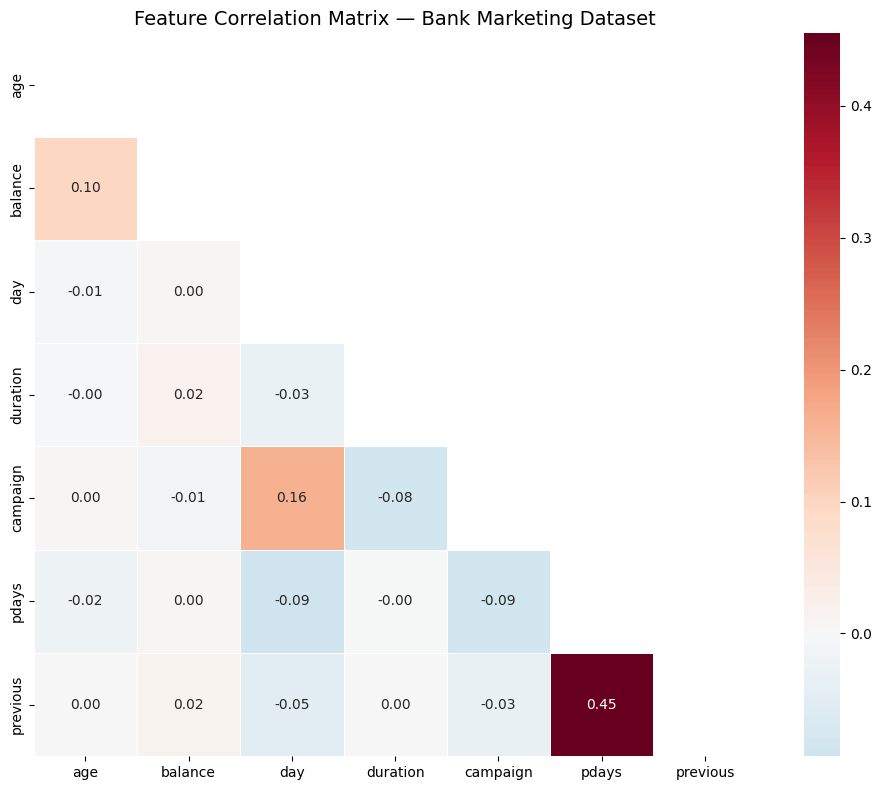


Feature pairs with |correlation| > 0.5:
  None found — features are relatively independent (good for ML).


In [39]:
# Select numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix — Bank Marketing Dataset', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Identify highly correlated pairs
high_corr_threshold = 0.5
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > high_corr_threshold:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print(f"\nFeature pairs with |correlation| > {high_corr_threshold}:")
if high_corr_pairs:
    for f1, f2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {f1} <-> {f2}: {corr:.3f}")
else:
    print("  None found — features are relatively independent (good for ML).")


<a name='4'></a>
## 5 - Infer a Data Schema

A schema defines the expected properties of the data: feature types, value ranges, presence constraints, and valid categorical domains.


### Exercise 3: Infer the Training Set Schema


In [40]:
# Infer the data schema from training statistics
schema = tfdv.infer_schema(train_stats)

# Display the schema
tfdv.display_schema(schema)


,Type,Presence,Valency,Domain
Feature name,,,,
'age',INT,required,,-
'job',STRING,required,,'job'
'marital',STRING,required,,'marital'
'education',STRING,required,,'education'
'default',STRING,required,,'default'
'balance',INT,required,,-
'housing',STRING,required,,'housing'
'loan',STRING,required,,'loan'
'contact',STRING,required,,'contact'


,Values
Domain,
'job',"'admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown'"
'marital',"'divorced', 'married', 'single'"
'education',"'primary', 'secondary', 'tertiary', 'unknown'"
'default',"'no', 'yes'"
'housing',"'no', 'yes'"
'loan',"'no', 'yes'"
'contact',"'cellular', 'telephone', 'unknown'"
'month',"'apr', 'aug', 'dec', 'feb', 'jan', 'jul', 'jun', 'mar', 'may', 'nov', 'oct', 'sep'"
'poutcome',"'failure', 'other', 'success', 'unknown'"


In [41]:
# Verify schema
print(f"Number of features in schema: {len(schema.feature)}")
print(f"\nFeature names and types:")
for feature in schema.feature:
    print(f"  {feature.name}: {feature.type} (domain: {feature.domain if feature.domain else 'N/A'})")


Number of features in schema: 17

Feature names and types:
  age: 2 (domain: N/A)
  job: 1 (domain: job)
  marital: 1 (domain: marital)
  education: 1 (domain: education)
  default: 1 (domain: default)
  balance: 2 (domain: N/A)
  housing: 1 (domain: housing)
  loan: 1 (domain: loan)
  contact: 1 (domain: contact)
  day: 2 (domain: N/A)
  month: 1 (domain: month)
  duration: 2 (domain: N/A)
  campaign: 2 (domain: N/A)
  pdays: 2 (domain: N/A)
  previous: 2 (domain: N/A)
  poutcome: 1 (domain: poutcome)
  y: 1 (domain: y)


<a name='5'></a>
## 6 - Calculate, Visualize and Fix Evaluation Anomalies



### Exercise 4: Compare Training and Evaluation Statistics


In [42]:
# Generate evaluation dataset statistics
eval_stats = tfdv.generate_statistics_from_dataframe(eval_df, stats_options=stats_options)

# Compare evaluation data with training data
tfdv.visualize_statistics(lhs_statistics=eval_stats, rhs_statistics=train_stats,
                          lhs_name='EVAL_DATASET', rhs_name='TRAIN_DATASET')


In [43]:
# Verify evaluation statistics
print(f"Number of features: {len(eval_stats.datasets[0].features)}")
print(f"Number of examples: {eval_stats.datasets[0].num_examples}")
print(f"First feature: {eval_stats.datasets[0].features[0].path.step[0]}")
print(f"Last feature: {eval_stats.datasets[0].features[-1].path.step[0]}")


Number of features: 17
Number of examples: 6782
First feature: age
Last feature: y


### Exercise 5: Detecting Anomalies


In [44]:
def calculate_and_display_anomalies(statistics, schema):
    '''
    Calculate and display anomalies.

    Parameters:
        statistics : Data statistics in DatasetFeatureStatisticsList format
        schema : Data schema in Schema format

    Returns:
        anomalies : The detected anomalies object
    '''
    anomalies = tfdv.validate_statistics(schema=schema, statistics=statistics)
    tfdv.display_anomalies(anomalies=anomalies)

    return anomalies

# Check evaluation data for anomalies
eval_anomalies = calculate_and_display_anomalies(eval_stats, schema=schema)


### Exercise 6: Fix Evaluation Anomalies in the Schema

With the Bank Marketing dataset, common anomalies include unexpected string values in categorical features like `job`, `education`, or `poutcome` that appear in eval but not training data. We fix these by expanding the schema domains.


In [45]:
# Fix anomalies by adding missing domain values from eval data
categorical_features = ['job', 'marital', 'education', 'default', 'housing',
                        'loan', 'contact', 'month', 'poutcome', 'y']

for feature_name in categorical_features:
    try:
        domain = tfdv.get_domain(schema, feature_name)
        for val in eval_df[feature_name].dropna().unique():
            if val not in list(domain.value):
                domain.value.append(val)
                print(f"Added '{val}' to '{feature_name}' domain")
    except Exception as e:
        pass

# Re-check anomalies after fixes
print("\n--- After fixing domains ---")
eval_anomalies = calculate_and_display_anomalies(eval_stats, schema=schema)



--- After fixing domains ---


<a name='5-1'></a>
### 6.1 Anomaly Summary Report



In [46]:
def generate_anomaly_report(statistics, schema, dataset_name="Dataset"):
    '''
    Generate a structured anomaly report from TFDV validation.

    Parameters:
        statistics: TFDV statistics object
        schema: TFDV schema object
        dataset_name: Name for the report header

    Returns:
        report_df: DataFrame with anomaly details
    '''
    anomalies = tfdv.validate_statistics(schema=schema, statistics=statistics)
    report_data = []

    for feature_name, anomaly in anomalies.anomaly_info.items():
        report_data.append({
            'Feature': feature_name,
            'Severity': str(anomaly.severity),
            'Short Description': anomaly.short_description,
            'Description': anomaly.description[:100] + '...' if len(anomaly.description) > 100 else anomaly.description,
        })

    print(f"{'='*60}")
    print(f"  ANOMALY REPORT: {dataset_name}")
    print(f"{'='*60}")

    if report_data:
        report_df = pd.DataFrame(report_data)
        print(f"Total anomalies detected: {len(report_data)}")
        print(f"Affected features: {', '.join([r['Feature'] for r in report_data])}")
        return report_df
    else:
        print("No anomalies found! Data is clean.")
        return pd.DataFrame()

# Generate reports for both splits
print("\n--- Evaluation Data Report ---")
eval_report = generate_anomaly_report(eval_stats, schema, "Evaluation Dataset")
if not eval_report.empty:
    display(eval_report)
else:
    print("All evaluation anomalies have been resolved!")



--- Evaluation Data Report ---
  ANOMALY REPORT: Evaluation Dataset
No anomalies found! Data is clean.
All evaluation anomalies have been resolved!


<a name='6'></a>
## 7 - Schema Environments

The label column (`y`) is dropped in serving data, so it will be flagged as an anomaly ('Column dropped'). We handle this by defining separate TRAINING and SERVING environments.


In [47]:
# Generate serving statistics with schema-aware options
options = tfdv.StatsOptions(schema=schema,
                            infer_type_from_schema=True,
                            feature_allowlist=approved_cols)

serving_stats = tfdv.generate_statistics_from_dataframe(serving_df, stats_options=options)

# Check anomalies before environment setup
print("=== Before environment configuration ===")
serving_anomalies = calculate_and_display_anomalies(serving_stats, schema=schema)


=== Before environment configuration ===


,Anomaly short description,Anomaly long description
Feature name,,
'y',Column dropped,Column is completely missing


In [48]:
# Fix any serving data domain mismatches
for feature_name in categorical_features:
    try:
        domain = tfdv.get_domain(schema, feature_name)
        if feature_name in serving_df.columns:
            for val in serving_df[feature_name].dropna().unique():
                if val not in list(domain.value):
                    domain.value.append(val)
                    print(f"Added '{val}' to '{feature_name}' domain for serving data")
    except Exception as e:
        pass

# Relax distribution constraints for features with minor deviations
for feat_name in ['poutcome', 'contact', 'education']:
    try:
        feat = tfdv.get_feature(schema, feat_name)
        feat.distribution_constraints.min_domain_mass = 0.9
    except:
        pass


### Exercise 9: Detecting Anomalies with Environments


In [49]:
# Define TRAINING and SERVING environments
schema.default_environment.append('TRAINING')
schema.default_environment.append('SERVING')

# Specify that 'y' (label) is not in SERVING environment
tfdv.get_feature(schema, 'y').not_in_environment.append('SERVING')

# Validate with environment parameter
serving_anomalies_with_env = tfdv.validate_statistics(
    statistics=serving_stats,
    schema=schema,
    environment='SERVING'
)
# Display anomalies
tfdv.display_anomalies(serving_anomalies_with_env)


<a name='7'></a>
## 8 - Check for Data Drift and Skew

Drift measures how data distributions change over time (eval vs previous eval). Skew measures differences between training and serving distributions. With ~45k records, these comparisons are statistically meaningful.


In [50]:
# Calculate skew for the 'marital' feature (categorical, good candidate)
marital_feature = tfdv.get_feature(schema, 'marital')
marital_feature.skew_comparator.infinity_norm.threshold = 0.03

# Calculate drift for the 'job' feature (many categories, likely to show drift)
job_feature = tfdv.get_feature(schema, 'job')
job_feature.drift_comparator.infinity_norm.threshold = 0.03

# Calculate skew for 'housing' feature (binary)
housing_feature = tfdv.get_feature(schema, 'housing')
housing_feature.skew_comparator.infinity_norm.threshold = 0.03

# Validate for skew and drift
skew_drift_anomalies = tfdv.validate_statistics(
    train_stats, schema,
    previous_statistics=eval_stats,
    serving_statistics=serving_stats
)

# Display results
tfdv.display_anomalies(skew_drift_anomalies)


If anomalies are detected, examine whether the distance exceeds the threshold significantly. With our shuffled 45k-record splits, small deviations are expected. In production you would:
1. Investigate root causes (data pipeline issues, population shifts, seasonal effects)
2. Adjust thresholds based on domain knowledge
3. Retrain the model if drift is significant


<a name='8'></a>
## 9 - Display Stats for Data Slices

Slicing lets us compare statistics across subgroups. This is especially important for the Bank Marketing dataset where different job types or education levels might have very different feature distributions.


In [51]:
def split_datasets(dataset_list):
    '''Split datasets from a DatasetFeatureStatisticsList into individual protocol buffers.'''
    datasets = []
    for dataset in dataset_list.datasets:
        proto_list = DatasetFeatureStatisticsList()
        proto_list.datasets.extend([dataset])
        datasets.append(proto_list)
    return datasets


def display_stats_at_index(index, datasets):
    '''Display statistics at the specified index.'''
    if index < len(datasets):
        print(datasets[index].datasets[0].name)
        tfdv.visualize_statistics(datasets[index])


def sliced_stats_for_slice_fn(slice_fn, approved_cols, dataframe, schema):
    '''Generate statistics for sliced data.'''
    slice_stats_options = tfdv.StatsOptions(
        schema=schema,
        slice_functions=[slice_fn],
        infer_type_from_schema=True,
        feature_allowlist=approved_cols
    )

    CSV_PATH = 'slice_sample.csv'
    dataframe.to_csv(CSV_PATH, index=False)

    sliced_stats = tfdv.generate_statistics_from_csv(CSV_PATH, stats_options=slice_stats_options)
    slice_info_datasets = split_datasets(sliced_stats)

    return slice_info_datasets


def display_stats_for_slice_name(slice_name, slice_datasets):
    '''Display statistics for a named slice.'''
    datasets_keys = {dataset.datasets[0].name: i for i, dataset in enumerate(slice_datasets)}
    if slice_name in datasets_keys:
        display_stats_at_index(datasets_keys[slice_name], slice_datasets)
    else:
        print(f"Slice '{slice_name}' not found. Available slices:")
        for name in datasets_keys:
            print(f"  - {name}")


In [52]:
# Generate slice function for the 'education' feature
slice_fn = slicing_util.get_feature_value_slicer(features={'education': None})

# Generate stats for sliced dataset
slice_datasets = sliced_stats_for_slice_fn(slice_fn, approved_cols, dataframe=train_df, schema=schema)

# Print available slices
print(f'Statistics generated for {len(slice_datasets)} slices:\n')
print('\n'.join([sliced.datasets[0].name for sliced in slice_datasets]))


Statistics generated for 5 slices:

All Examples
education_secondary
education_tertiary
education_primary
education_unknown


In [53]:
# Display statistics for the 'tertiary' education slice
display_stats_for_slice_name('education_tertiary', slice_datasets)


education_tertiary


<a name='8-1'></a>
### 9.1 Multi-feature Slicing

In [54]:
slice_fn_marital = slicing_util.get_feature_value_slicer(features={'marital': None})
marital_slice_datasets = sliced_stats_for_slice_fn(slice_fn_marital, approved_cols, dataframe=train_df, schema=schema)

print(f'Marital status slices generated:\n')
print('\n'.join([sliced.datasets[0].name for sliced in marital_slice_datasets]))

# Display stats for married clients
display_stats_for_slice_name('marital_married', marital_slice_datasets)


Marital status slices generated:

All Examples
marital_married
marital_single
marital_divorced
marital_married


In [55]:
slice_fn_job = slicing_util.get_feature_value_slicer(features={'job': None})
job_slice_datasets = sliced_stats_for_slice_fn(slice_fn_job, approved_cols, dataframe=train_df, schema=schema)

print(f'Job type slices generated ({len(job_slice_datasets)} slices):\n')
print('\n'.join([sliced.datasets[0].name for sliced in job_slice_datasets]))


Job type slices generated (13 slices):

All Examples
job_blue-collar
job_services
job_student
job_management
job_admin.
job_technician
job_self-employed
job_entrepreneur
job_retired
job_unemployed
job_housemaid
job_unknown


<a name='9'></a>
## 10 - Data Quality Score Dashboard



In [56]:

def compute_data_quality_score(df, schema, statistics):
    '''
    Compute a composite data quality score for a dataset.

    Dimensions:
        1. Completeness: % of non-null, non-'unknown' values
        2. Consistency: % of features with no schema anomalies
        3. Uniqueness: Ratio of unique values in categorical features
        4. Validity: % of values within expected ranges

    Returns:
        scores: dict with dimension scores and overall score
    '''
    scores = {}

    # 1. Completeness Score (0-100)
    # Account for both NaN and 'unknown' as missing
    total_cells = df.shape[0] * df.shape[1]
    non_null_cells = df.notna().sum().sum()
    unknown_cells = sum((df[col] == 'unknown').sum() for col in df.columns if df[col].dtype == 'object')
    scores['Completeness'] = ((non_null_cells - unknown_cells) / total_cells) * 100

    # 2. Consistency Score (0-100)
    anomalies = tfdv.validate_statistics(schema=schema, statistics=statistics)
    num_anomalies = len(anomalies.anomaly_info)
    num_features = len(df.columns)
    scores['Consistency'] = ((num_features - num_anomalies) / num_features) * 100

    # 3. Uniqueness Score (0-100) - for categorical features
    cat_cols = df.select_dtypes(include=['object']).columns
    if len(cat_cols) > 0:
        uniqueness_ratios = []
        for col in cat_cols:
            unique_ratio = df[col].nunique() / max(df[col].count(), 1)
            uniqueness_ratios.append(min(unique_ratio * 20, 1.0))  # Scale appropriately
        scores['Uniqueness'] = np.mean(uniqueness_ratios) * 100
    else:
        scores['Uniqueness'] = 100.0

    # 4. Validity Score (0-100) - numeric values within reasonable ranges
    num_cols = df.select_dtypes(include=[np.number]).columns
    if len(num_cols) > 0:
        validity_checks = []
        for col in num_cols:
            col_data = df[col].dropna()
            if len(col_data) > 0:
                # Check for negative values in features that shouldn't have them
                if col in ['age', 'duration', 'campaign', 'previous']:
                    valid_ratio = (col_data >= 0).mean()
                else:
                    valid_ratio = 1.0  # balance can be negative, pdays=-1 means no contact
                validity_checks.append(valid_ratio)
        scores['Validity'] = np.mean(validity_checks) * 100 if validity_checks else 100.0
    else:
        scores['Validity'] = 100.0

    # Overall score (weighted average)
    weights = {'Completeness': 0.3, 'Consistency': 0.3, 'Uniqueness': 0.15, 'Validity': 0.25}
    scores['Overall'] = sum(scores[dim] * weights[dim] for dim in weights)

    return scores

# Compute scores for all splits
train_scores = compute_data_quality_score(train_df, schema, train_stats)
eval_scores = compute_data_quality_score(eval_df, schema, eval_stats)

print("=" * 60)
print("        DATA QUALITY SCORE DASHBOARD")
print("=" * 60)
print(f"{'Dimension':<20} {'Training':>12} {'Evaluation':>12}")
print("-" * 60)
for dim in ['Completeness', 'Consistency', 'Uniqueness', 'Validity']:
    print(f"{dim:<20} {train_scores[dim]:>11.1f}% {eval_scores[dim]:>11.1f}%")
print("-" * 60)
print(f"{'OVERALL':<20} {train_scores['Overall']:>11.1f}% {eval_scores['Overall']:>11.1f}%")
print("=" * 60)


        DATA QUALITY SCORE DASHBOARD
Dimension                Training   Evaluation
------------------------------------------------------------
Completeness                93.2%        93.2%
Consistency                100.0%       100.0%
Uniqueness                   0.3%         1.4%
Validity                   100.0%       100.0%
------------------------------------------------------------
OVERALL                     83.0%        83.2%


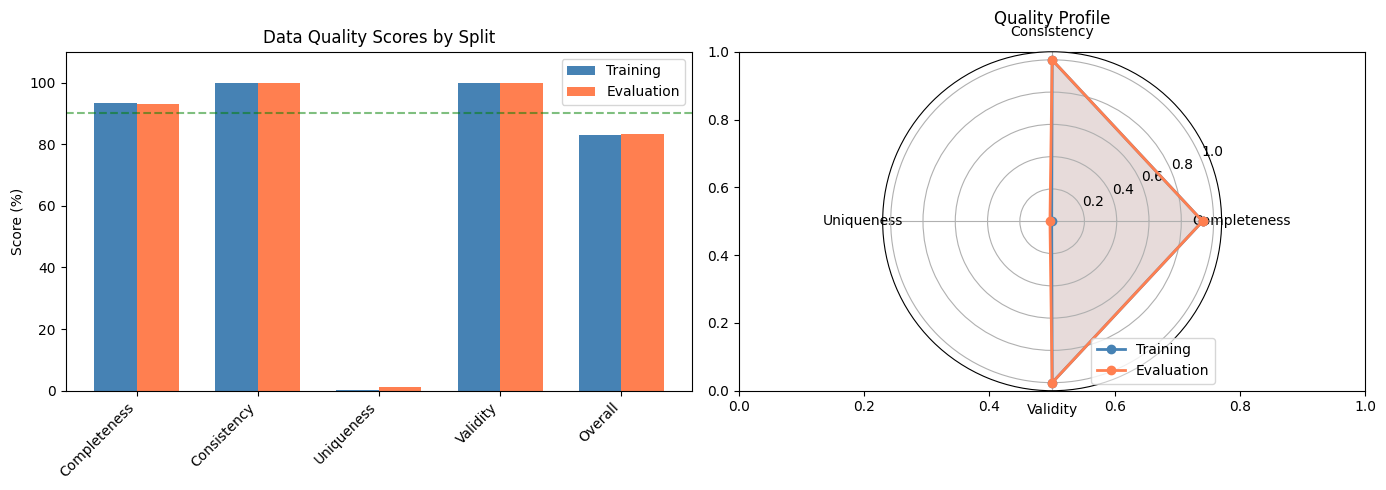

Data quality dashboard saved to data_quality_dashboard.png


In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dimensions = ['Completeness', 'Consistency', 'Uniqueness', 'Validity', 'Overall']
train_vals = [train_scores[d] for d in dimensions]
eval_vals = [eval_scores[d] for d in dimensions]

x = np.arange(len(dimensions))
width = 0.35

bars1 = axes[0].bar(x - width/2, train_vals, width, label='Training', color='steelblue')
bars2 = axes[0].bar(x + width/2, eval_vals, width, label='Evaluation', color='coral')
axes[0].set_ylabel('Score (%)')
axes[0].set_title('Data Quality Scores by Split')
axes[0].set_xticks(x)
axes[0].set_xticklabels(dimensions, rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 110)
axes[0].axhline(y=90, color='green', linestyle='--', alpha=0.5, label='Target (90%)')

# Radar chart for overall quality profile
categories = ['Completeness', 'Consistency', 'Uniqueness', 'Validity']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

train_radar = [train_scores[c] / 100 for c in categories] + [train_scores[categories[0]] / 100]
eval_radar = [eval_scores[c] / 100 for c in categories] + [eval_scores[categories[0]] / 100]

ax2 = plt.subplot(122, polar=True)
ax2.plot(angles, train_radar, 'o-', linewidth=2, label='Training', color='steelblue')
ax2.fill(angles, train_radar, alpha=0.15, color='steelblue')
ax2.plot(angles, eval_radar, 'o-', linewidth=2, label='Evaluation', color='coral')
ax2.fill(angles, eval_radar, alpha=0.15, color='coral')
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories)
ax2.set_title('Quality Profile', pad=20)
ax2.legend(loc='lower right')

plt.tight_layout()
plt.savefig('data_quality_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Data quality dashboard saved to data_quality_dashboard.png")


<a name='10'></a>
## 11 - Freeze the Schema

Store the validated schema for use in production data validation pipelines.


In [58]:
OUTPUT_DIR = "output"
file_io.recursive_create_dir(OUTPUT_DIR)

# Save the frozen schema
schema_file = os.path.join(OUTPUT_DIR, 'schema.pbtxt')
tfdv.write_schema_text(schema, schema_file)

print(f"Schema saved to: {schema_file}")
print(f"Schema contains {len(schema.feature)} features")
print(f"Environments defined: {list(schema.default_environment)}")


Schema saved to: output/schema.pbtxt
Schema contains 17 features
Environments defined: ['TRAINING', 'SERVING']


## Summary

This modified TFDV lab demonstrates a complete data validation pipeline using the **UCI Bank Marketing** dataset (~45,211 records, 17 features):

1. **New Dataset**: UCI Bank Marketing — comparable in size to the original (~45k vs ~100k records), with a rich mix of categorical and numerical features ideal for drift/skew detection
2. **Missing Value Analysis**: Visual analysis of 'unknown' encoded missing values and data completeness patterns
3. **Feature Correlation Heatmap**: Identifying redundant and highly correlated features
4. **Anomaly Summary Report**: Structured DataFrame reporting for production monitoring
5. **Multi-feature Slicing**: Job-type and marital-status slicing for fairness analysis in financial ML
6. **Data Quality Score Dashboard**: Automated scoring across Completeness, Consistency, Uniqueness, and Validity dimensions with radar chart visualization

These additions reflect real-world MLOps practices for data monitoring and quality assurance in production ML systems.

---

